In [1]:
# Explainability Analysis Notebook
# BiLSTM + Attention NLP Classification Model
# Includes: Attention, IG, LRP, SHAP

import torch
import pickle
import numpy as np


In [2]:
print()

In [3]:
from model import LSTMAttentionClassifier
import os
device = "cuda" if torch.cuda.is_available() else "cpu"
current_directory = os.getcwd()

saved_model_path = os.path.join(current_directory, '..', 'saved_model')
vocab_path = os.path.join(saved_model_path, 'vocab.pkl')
label_encoder_path = os.path.join(saved_model_path, 'label_encoder.pkl')
model_path = os.path.join(saved_model_path, 'lstm_attention_model.pt')

# Load vocab + label encoder
with open(vocab_path, "rb") as f:
    vocab = pickle.load(f)
with open(label_encoder_path, "rb") as f:
    label_encoder = pickle.load(f)

# Rebuild model
model = LSTMAttentionClassifier(
    vocab_size=len(vocab),
    embedding_dim=300,
    hidden_dim=128,
    output_dim=len(label_encoder.classes_),
    bidirectional=True
)

# Load weights
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("Model, vocab, and label encoder loaded.")


Model, vocab, and label encoder loaded.


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


In [4]:
def encode_text(text, vocab):
    tokens = text.lower().split()
    ids = [vocab.get(tok, 1) for tok in tokens]
    return tokens, torch.tensor([ids], device=device)


In [5]:
sample_text = (
    "I keep pretending that I'm fine, but every night I feel like I'm falling apart. "
    "I don't know how much longer I can hold everything together."
)

misclassified_text = (
    "I'm exhausted and stressed from work. Nothing feels meaningful lately, "
    "but I know I’m not going to do anything to myself."
)
texts_for_shap = [
    "I feel hopeless and don’t see a future for myself.",
    "I’m stressed from school but trying to stay positive.",
    "Life has been tough, but I'm slowly getting better.",
    "Sometimes I think everyone would be better off without me.",
    "Had a bad day today, but talking to friends helped."
]



In [ ]:
from explainability import (
    plot_attention, highlight_text, plot_attention_distribution
)

from advanced_xai import (
    integrated_gradients_for_text,
    shap_for_texts
)


In [11]:
tokens, ids = encode_text(sample_text, vocab)

with torch.no_grad():
    logits, attn = model(ids)

attn_np = attn.squeeze().cpu().numpy()
attention_example_path = os.path.join(saved_model_path, 'attention_example.png')
attention_distribution_path = os.path.join(saved_model_path, 'attention_distribution.png')

plot_attention(sample_text, attn_np, save_path=attention_example_path)
highlight_text(sample_text, attn_np)
plot_attention_distribution(attn_np, save_path=attention_distribution_path)


[Saved] Token-level attention heatmap → /home/ubuntu/NLP/final_project/Final-Project-Group1/Code/lstm/Utils/../saved_model/attention_example.png

========== Highlighted Text (Token → Attention) ==========
 I   keep   pretending   that   I'm   fine,   but   every   night   I   feel   like   I'm   falling   apart.   I   don't   know   how   much   longer   I   can   hold   everything   together. 


[Saved] Attention distribution plot - /home/ubuntu/NLP/final_project/Final-Project-Group1/Code/lstm/Utils/../saved_model/attention_distribution.png


In [12]:
ig_sample_path = os.path.join(saved_model_path, 'ig_sample.png')

tokens_ig, ig_scores = integrated_gradients_for_text(
    model=model,
    text=sample_text,
    vocab=vocab,
    label_encoder=label_encoder,
    device=device,
    n_steps=50,
    save_path=ig_sample_path
)

list(zip(tokens_ig, ig_scores))


[Saved] Integrated Gradients plot → /home/ubuntu/NLP/final_project/Final-Project-Group1/Code/lstm/Utils/../saved_model/ig_sample.png


[('i', -0.6558885),
 ('keep', 0.073973864),
 ('pretending', -0.15722828),
 ('that', -0.36211932),
 ("i'm", -0.21740411),
 ('fine,', -0.02743204),
 ('but', -0.5132722),
 ('every', -0.152997),
 ('night', -0.07183285),
 ('i', 0.021914355),
 ('feel', -0.0046647936),
 ('like', -0.013730723),
 ("i'm", 0.19364382),
 ('falling', 0.30648425),
 ('apart.', 0.022813007),
 ('i', -0.17648849),
 ("don't", -0.010637436),
 ('know', 0.08752569),
 ('how', 0.32338688),
 ('much', 0.4678353),
 ('longer', 1.0594585),
 ('i', 0.53483963),
 ('can', 1.1840278),
 ('hold', 4.944088),
 ('everything', -0.95643854),
 ('together.', 0.7155609)]

In [14]:
shap_values, token_id_matrix, token_lists = shap_for_texts(
    model=model,
    texts=texts_for_shap,
    vocab=vocab,
    device=device,
    max_len=40,
    num_background=3,
    num_samples=60
)

shap_values


100%|██████████| 5/5 [00:00<00:00, 17.74it/s]


array([[[ 0.02776877, -0.02776877],
        [-0.08399142,  0.08399142],
        [-0.15488232,  0.15488231],
        [ 0.10191778, -0.10191779],
        [ 0.03280828, -0.03280829],
        [-0.09847906,  0.09847907],
        [-0.03368906,  0.03368906],
        [-0.00965643,  0.00965643],
        [ 0.15579858, -0.15579858],
        [-0.0373659 ,  0.03736589],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.        ],
        [ 0.        ,  0.   

100%|██████████| 5/5 [00:00<00:00, 18.40it/s]
/tmp/ipykernel_83299/3840166876.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  pred_class = np.argmax(model(torch.tensor([token_id_matrix[sample_idx]], device=device))[0].detach().cpu().numpy())


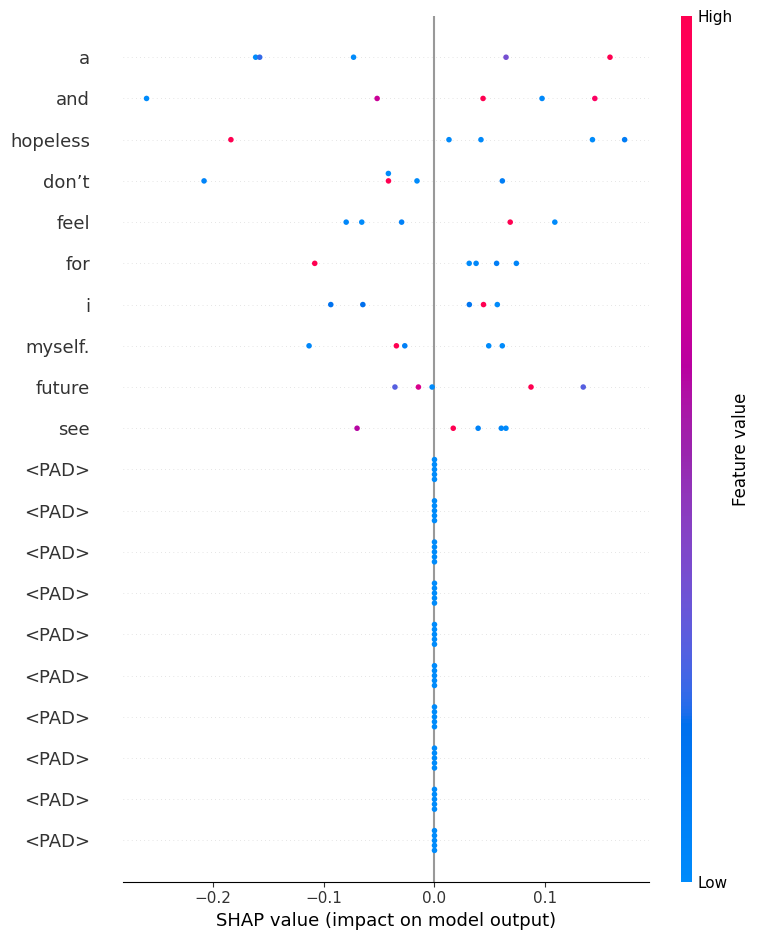

In [16]:
shap_values, token_id_matrix, token_lists = shap_for_texts(
    model=model,
    texts=texts_for_shap,
    vocab=vocab,
    device=device,
    max_len=40,
    num_background=3,
    num_samples=60
)

# Pick sample 0:
sample_idx = 0
pred_class = np.argmax(model(torch.tensor([token_id_matrix[sample_idx]], device=device))[0].detach().cpu().numpy())

# Extract class-specific SHAP
class_shap = shap_values[..., pred_class]

names = token_lists[sample_idx] + ["<PAD>"] * (token_id_matrix.shape[1] - len(token_lists[sample_idx]))

shap.summary_plot(
    class_shap,
    token_id_matrix,
    feature_names=names
)
